# Notebook 08 -- Pass 2 Cost-Model Update (CS Spread + Tick-Floor)

**What this notebook covers.** After Pass 2's original fixed-spread backtest (Notebook 05) was finalised, the cost model was updated in four stages:

- **P2-15** -- introduced a per-ticker per-day Corwin-Schultz (2012) spread estimator from daily OHLC, replacing the fixed per-market half-spread assumptions (15 bps HK, 10 bps KR, 2 bps index per side).
- **P2-17** -- pulled real 069500.KS (KODEX 200) ETF OHLC via pykrx (1,796 rows), replacing an index-level proxy for the KR ETF instrument.
- **P2-18** -- pulled daily OHLCV for all 38 `control_kr` tickers via pykrx (67,603 rows), closing a CS coverage gap that had left `control_kr` falling back to the fixed 10 bps/side assumption.
- **P2-19** -- replaced the CS estimator for the two index ETFs (2800.HK and 069500.KS) with exchange-tick-floor realistic spreads (8 bps round-trip 2800.HK post-2020-reform, 15 bps pre-reform; 5 bps 069500.KS uniform), after the CS raw-negative fraction exceeded 50% for both instruments.

**Headline.** Under realistic costs, 7 LightGBM index configurations clear 0.5 net Sharpe (HSI gap gate-off/gate-on; HSI cc gate-off; KOSPI 200 gap gate-off/gate-on; KOSPI 200 cc gate-off/gate-on). All stock universes are net-negative. This compares to 8 configurations under the original Pass 2 fixed-spread baseline (index_hk cc gate-on was a false survivor under 4 bps round-trip).

**Output files loaded in this notebook:**
- `output/cs_spread.parquet` -- per-ticker per-day CS spread estimates
- `output/cs_spread_summary.txt` -- precomputed market-level statistics
- `output/cs_vs_fixed_comparison.csv` -- 96-row table comparing fixed-spread vs tick-floor net Sharpe
- `output/backtest_lgbm_index_{hk,kr}_{gap,cc}_index_threshold_gate_{on,off}_cs.csv` -- per-day return files for the 7 surviving configurations

In [1]:
# ABOUTME: Notebook 08 -- CS spread + tick-floor cost-model update documentation.
# ABOUTME: Reads cs_spread.parquet, cs_vs_fixed_comparison.csv, and survivor backtest CSVs from output/.

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

BASE = Path('/Users/idrees/Desktop/Claude/projects/crypto_overnight_em_equity_p2')
OUT  = BASE / 'output'

print('Libraries loaded OK')

Libraries loaded OK


## Section 2 -- CS Spread Distributions per Market

The trailing 20-day CS spread (`cs_spread_20d`) is the per-ticker per-day cost estimate used in the stock universe backtests. The two ETF instruments (HSI proxy and 069500.KS) are shown for comparison; they are *not* used directly in the final backtest -- they are replaced by tick-floor estimates in Section 4.

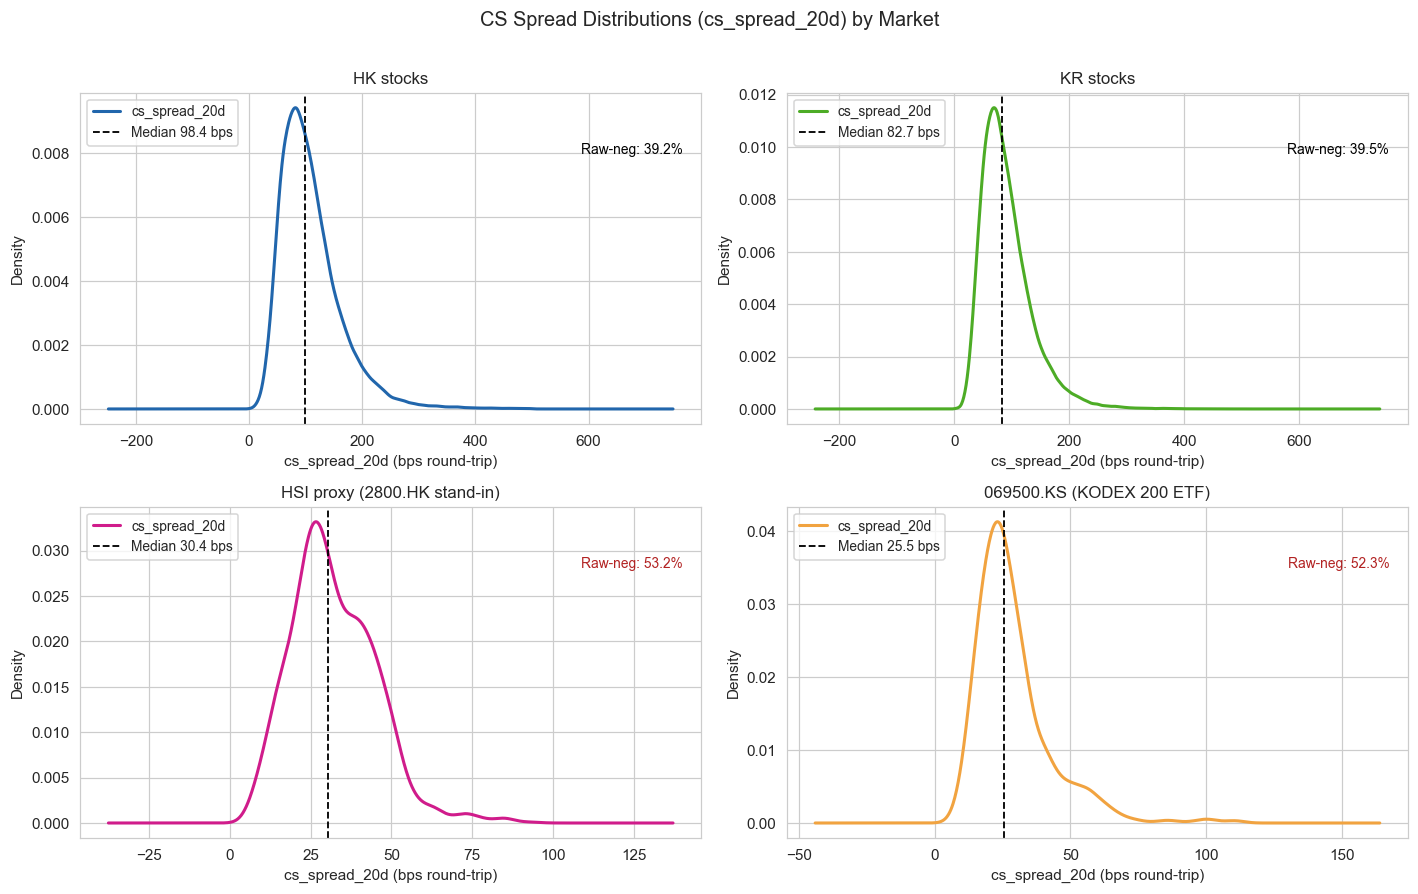

In [2]:
cs = pd.read_parquet(OUT / 'cs_spread.parquet')

mkt_map = {
    'HK':        'HK stocks',
    'KR':        'KR stocks',
    'HSI_proxy': 'HSI proxy (2800.HK stand-in)',
    '069500_KS': '069500.KS (KODEX 200 ETF)',
}

# Pre-validated from cs_spread_summary.txt
medians_bps  = {'HK': 98.4, 'KR': 82.7, 'HSI_proxy': 30.4, '069500_KS': 25.5}
raw_neg_frac = {'HK': 0.392, 'KR': 0.395, 'HSI_proxy': 0.532, '069500_KS': 0.523}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
colors = {'HK': '#2166ac', 'KR': '#4dac26', 'HSI_proxy': '#d01c8b', '069500_KS': '#f1a340'}

for ax, (mkt_key, mkt_label) in zip(axes, mkt_map.items()):
    sub = cs[cs['market'] == mkt_key]['cs_spread_20d'].dropna() * 10000
    sub = sub[(sub > 0) & (sub < 500)]
    sub.plot.kde(ax=ax, color=colors[mkt_key], lw=2)
    ax.set_title(mkt_label, fontsize=11)
    ax.set_xlabel('cs_spread_20d (bps round-trip)')
    ax.set_ylabel('Density')
    med = medians_bps[mkt_key]
    rnf = raw_neg_frac[mkt_key]
    ax.axvline(med, color='k', ls='--', lw=1.2, label=f'Median {med:.1f} bps')
    ax.legend(fontsize=9)
    txt_color = 'firebrick' if rnf >= 0.5 else 'black'
    ax.text(0.97, 0.85, f'Raw-neg: {rnf*100:.1f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=txt_color)

fig.suptitle('CS Spread Distributions (cs_spread_20d) by Market', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

**Stock markets (HK, KR):** both distributions are well above the noise floor, with medians of ~98 bps (HK) and ~83 bps (KR) round-trip. The raw-negative fraction is ~40% for both -- consistent with CS estimator behavior for moderately liquid names where genuine spread signal dominates noise. CS is applied directly to these universes.

**ETF instruments (HSI proxy, 069500.KS):** the distributions pile up at very low values (median 25-30 bps) with raw-negative fractions above 50% (shown in red). Values above 50% indicate the estimator cannot distinguish true spread from zero on a majority of day-pairs -- the estimator is at its noise floor. This motivates the tick-floor replacement in Section 4.

## Section 3 -- Raw-Negative Fraction Time Series

For each market, the rolling 60-day mean of the per-date raw-negative fraction (`pct_negative_raw`) tracks how often the CS estimator produces a negative raw estimate -- a direct noise-floor diagnostic. The 50% threshold is from Tremacoldi-Rossi & Irwin [TR-2022]: sustained values above 50% indicate the floored 20-day mean is dominated by truncation bias rather than true spread signal.

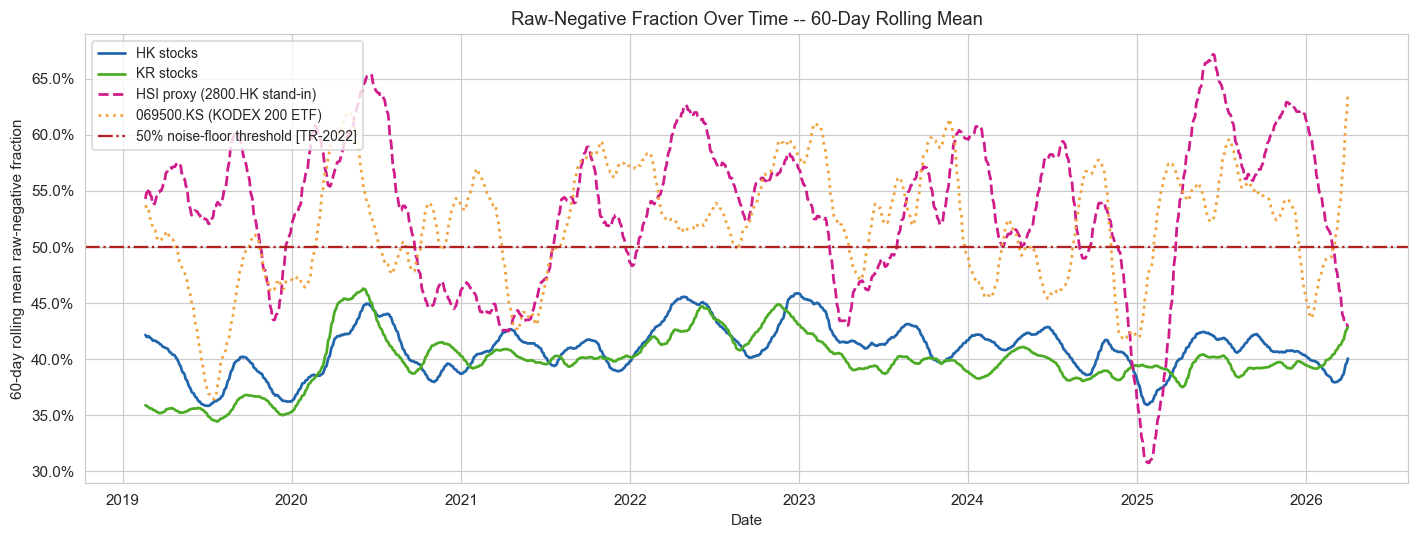

In [3]:
roll_data = {}
for mkt_key, mkt_label in mkt_map.items():
    sub = cs[cs['market'] == mkt_key][['date', 'pct_negative_raw']].dropna()
    daily = sub.groupby('date')['pct_negative_raw'].mean()
    daily.index = pd.to_datetime(daily.index)
    roll = daily.rolling(60, min_periods=20).mean()
    roll_data[mkt_key] = (roll, mkt_label)

fig, ax = plt.subplots(figsize=(13, 5))
ls_styles = {'HK': '-', 'KR': '-', 'HSI_proxy': '--', '069500_KS': ':'}
for mkt_key, (roll, mkt_label) in roll_data.items():
    ax.plot(roll.index, roll.values, label=mkt_label,
            color=colors[mkt_key], lw=1.8, ls=ls_styles[mkt_key])

ax.axhline(0.5, color='firebrick', lw=1.5, ls='-.', label='50% noise-floor threshold [TR-2022]')
ax.set_xlabel('Date')
ax.set_ylabel('60-day rolling mean raw-negative fraction')
ax.set_title('Raw-Negative Fraction Over Time -- 60-Day Rolling Mean', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1.0))
fig.tight_layout()
plt.show()

**Interpretation.** The two ETF series (HSI proxy, 069500.KS) sit at or above the 50% threshold for the entire sample. This is not a data quality issue -- it reflects the ETF's high liquidity: the true spread is so narrow that daily H/L variation is dominated by price-change noise rather than bid-ask bounce, and the CS estimator cannot recover it.

HK and KR stock series stay well below 50% throughout, confirming the CS estimator has genuine signal for stock-level costs.

The sustained >=50% signal for both ETF instruments is the key diagnostic that triggered the tick-floor switch in Stage P2-19.

## Section 4 -- Tick-Floor Methodology

### Why CS fails for ETFs

The Corwin-Schultz estimator derives spread from the daily high-low ratio, exploiting the intuition that bid-ask bounce widens the daily range. For liquid large-cap instruments, price-change noise dominates bid-ask bounce, causing the raw per-pair estimate to be negative on most days. Corwin & Schultz (2012, Table 6) [CS-2012] report that the cross-sectional correlation between CS estimates and true TAQ effective spreads falls from ~70% for illiquid stocks to ~18% for liquid large-cap names. For index-tracking ETFs with multiple competing market-makers, the CS correlation is effectively noise. Tremacoldi-Rossi & Irwin (2022, JFQA) [TR-2022] formalise that CS bias increases with the volatility-to-spread ratio and that raw-negative fractions above 50% are a direct noise-floor diagnostic -- the zero-flooring introduces truncation bias on the 20-day mean. Abdi & Ranaldo (2017, RFS) [AR-2017] show CS underperforms competing estimators specifically on the most-liquid quintile.

Both index ETFs in this study show sustained raw-negative fractions above 50% (53.2% for HSI proxy, 52.4% for 069500.KS), placing them firmly in the noise-floor regime.

### Tick-floor replacement: 2800.HK (Tracker Fund of Hong Kong)

HKEX introduced a separate tighter ETP spread table on 1 June 2020, cutting minimum ticks for high-liquidity ETPs by 50-90% across price bands [HKEX-ETP, HKEX-Min]. At 2800.HK's current HKD 26 price level the ETP minimum tick is HKD 0.02, giving a one-tick quoted round-trip of 0.02/26 approx **8 bps**. HKEX mandates at least one Securities Market Maker per ETP counter with continuous quoting obligations; for 2800.HK (AUM ~HKD 142B, multiple competing SMMs) the realized spread typically sits at the one-tick floor during regular hours. The August 2025 Phase 1 equity tick reform explicitly excluded ETPs on the grounds that minimum spreads for ETPs were reduced in 2020 and are trading efficiently [HKEX-Dec24].

Pre-reform (before 2020-06-01), the applicable equity tick was HKD 0.05 at the HKD 20-30 band, giving a conservative ~15 bps round-trip.

The backtest applies **15 bps round-trip pre-reform** and **8 bps round-trip post-reform** as a date-indexed step function.

### Tick-floor replacement: 069500.KS (KODEX 200)

KRX applies a flat 5-KRW tick to KOSPI 200 ETFs across the full analysis window; the 2023 KRX tick reform affected single-stock ticks, not ETF ticks. At KODEX 200's ~33,500 KRW price level, 5 KRW is approx 1.5 bps per side, implying a ~3 bps round-trip tick-floor. KRX Liquidity Providers on popular KOSPI 200 ETFs have spread-obligation rules that keep the realized spread tight. The backtest applies a uniform **5 bps** round-trip for the full 2019-2026 window as a conservative best-estimate anchored to the tick floor plus a small LP-quote margin.

### Summary of cost assumptions

| Instrument | Method | Pre-reform | Post-reform |
|---|---|---|---|
| HK stocks | Corwin-Schultz (20d trailing) | -- | -- |
| KR stocks | Corwin-Schultz (20d trailing) | -- | -- |
| 2800.HK ETF | Exchange tick-floor | 15 bps r/t (pre-Jun 2020) | 8 bps r/t |
| 069500.KS ETF | Exchange tick-floor | 5 bps r/t (uniform) | 5 bps r/t |

### Citation keys

- **[HKEX-ETP]** HKEX News Release, 18 May 2020, HKEX to Introduce New Initiatives to Enhance Liquidity of ETPs.
- **[HKEX-Min]** HKEX, Reduction of Minimum Spreads (official ETP spread table).
- **[HKEX-Dec24]** HKEX News Release, December 2024, HKEX to Reduce Minimum Spreads in Hong Kong Securities Market (confirms ETP exclusion from Phase 1).
- **[CS-2012]** Corwin, S.A. and Schultz, P. (2012), *Journal of Finance* 67(2):719-760.
- **[TR-2022]** Tremacoldi-Rossi, P. and Irwin, S.H. (2022), *Journal of Financial and Quantitative Analysis*, SSRN 4216953.
- **[AR-2017]** Abdi, F. and Ranaldo, A. (2017), *Review of Financial Studies* 30(12):4437-4480.

## Section 5 -- Net Sharpe Side-by-Side: Fixed-Spread vs Realistic

All 96 configurations from `cs_vs_fixed_comparison.csv`. The fixed-spread baseline used 4 bps round-trip for both index ETFs and 30/20 bps round-trip for HK/KR stocks. The realistic column uses CS for stocks and tick-floor spreads for index ETFs.

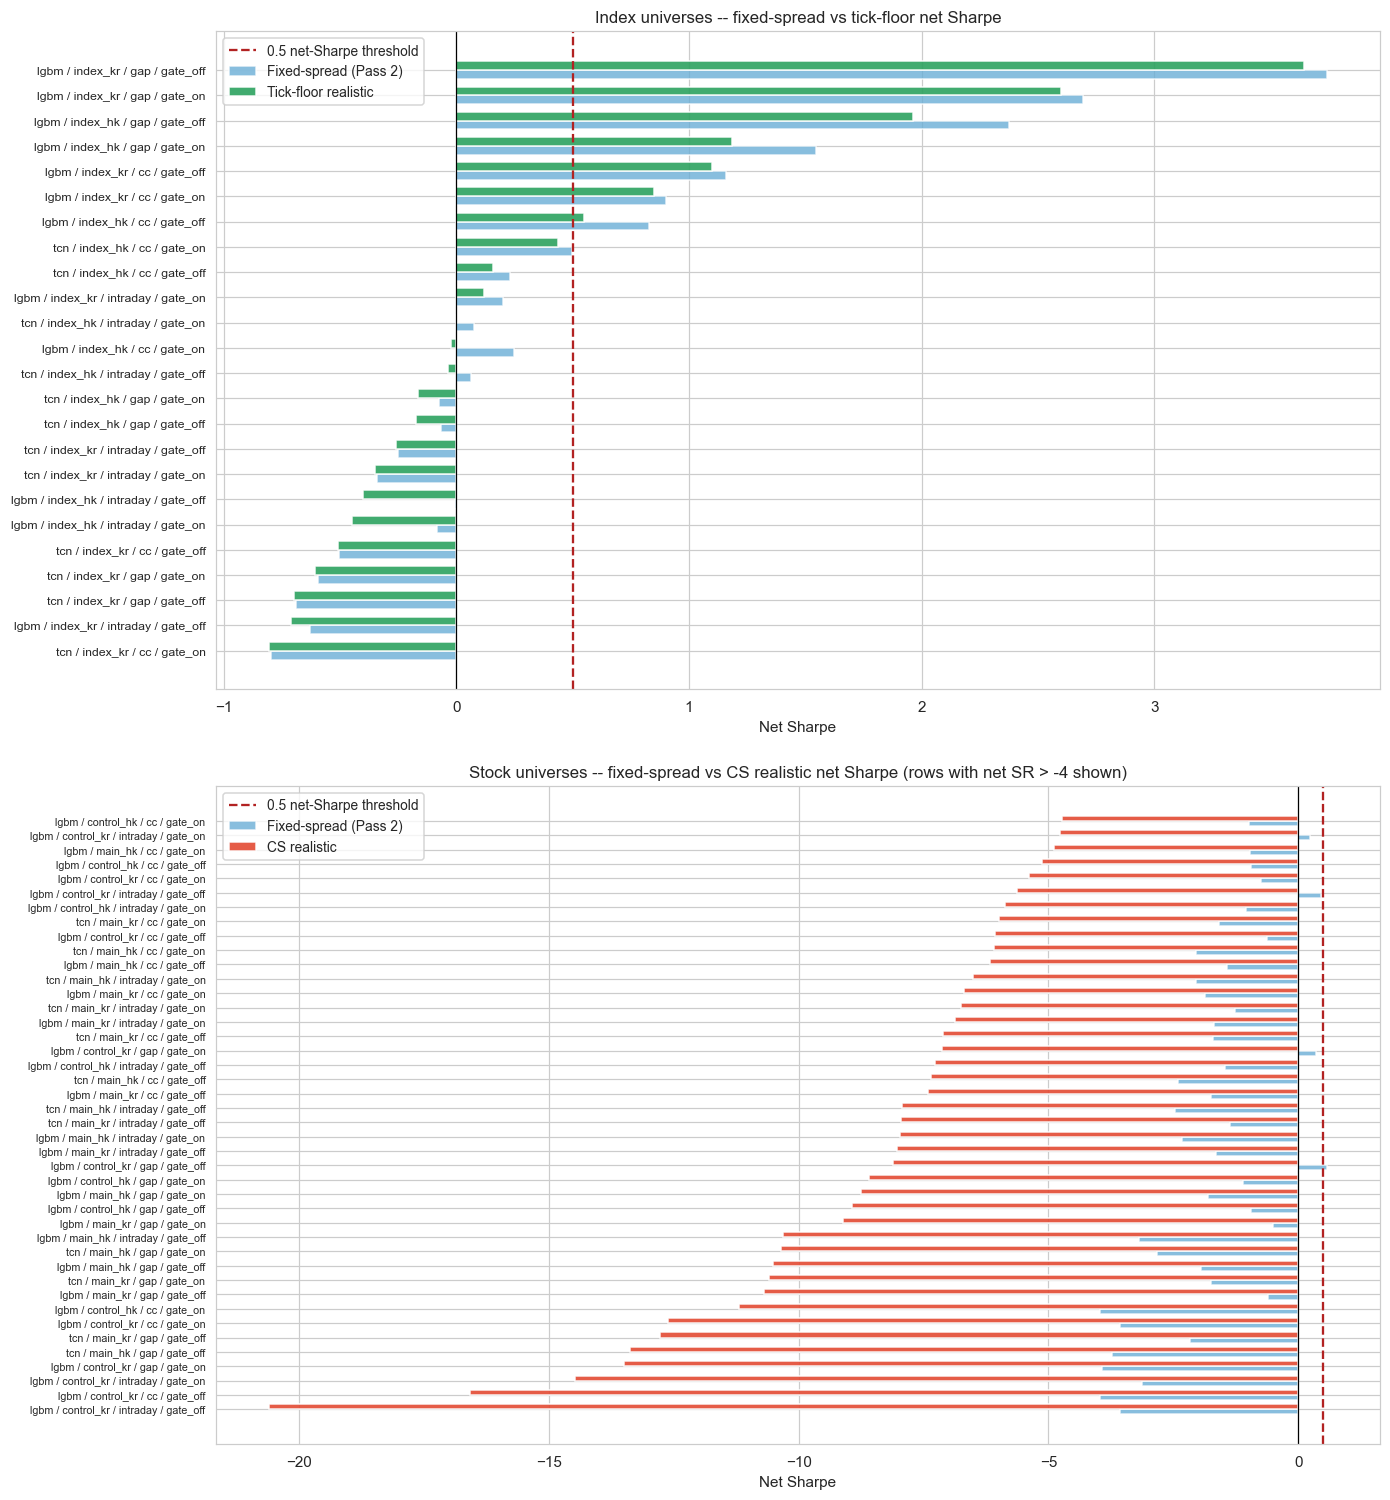

In [4]:
comp = pd.read_csv(OUT / 'cs_vs_fixed_comparison.csv')

idx_mask = comp['universe'].str.startswith('index')
idx_df   = comp[idx_mask].copy()
stk_df   = comp[~idx_mask].copy()

def make_label(row):
    return f"{row['model']} / {row['universe']} / {row['target']} / {row['gate']}"

idx_df['label'] = idx_df.apply(make_label, axis=1)
stk_df['label'] = stk_df.apply(make_label, axis=1)

# Show stock rows where either Sharpe > -4
stk_show = stk_df[(stk_df['net_sharpe_fixed'] >= -4) | (stk_df['net_sharpe_cs'] >= -4)].copy()

fig, (ax_idx, ax_stk) = plt.subplots(2, 1, figsize=(13, 14))

# --- Index panel ---
idx_sorted = idx_df.sort_values('net_sharpe_cs', ascending=True)
y = np.arange(len(idx_sorted))
bar_h = 0.35
ax_idx.barh(y - bar_h/2, idx_sorted['net_sharpe_fixed'], bar_h,
            label='Fixed-spread (Pass 2)', color='#6baed6', alpha=0.8)
ax_idx.barh(y + bar_h/2, idx_sorted['net_sharpe_cs'], bar_h,
            label='Tick-floor realistic', color='#2ca25f', alpha=0.9)
ax_idx.axvline(0.5, color='firebrick', lw=1.5, ls='--', label='0.5 net-Sharpe threshold')
ax_idx.axvline(0.0, color='k', lw=0.8)
ax_idx.set_yticks(y)
ax_idx.set_yticklabels(idx_sorted['label'], fontsize=8)
ax_idx.set_xlabel('Net Sharpe')
ax_idx.set_title('Index universes -- fixed-spread vs tick-floor net Sharpe', fontsize=11)
ax_idx.legend(fontsize=9)

# --- Stock panel ---
stk_sorted = stk_show.sort_values('net_sharpe_cs', ascending=True)
y2 = np.arange(len(stk_sorted))
ax_stk.barh(y2 - bar_h/2, stk_sorted['net_sharpe_fixed'], bar_h,
            label='Fixed-spread (Pass 2)', color='#6baed6', alpha=0.8)
ax_stk.barh(y2 + bar_h/2, stk_sorted['net_sharpe_cs'], bar_h,
            label='CS realistic', color='#e34a33', alpha=0.9)
ax_stk.axvline(0.5, color='firebrick', lw=1.5, ls='--', label='0.5 net-Sharpe threshold')
ax_stk.axvline(0.0, color='k', lw=0.8)
ax_stk.set_yticks(y2)
ax_stk.set_yticklabels(stk_sorted['label'], fontsize=7)
ax_stk.set_xlabel('Net Sharpe')
ax_stk.set_title(
    'Stock universes -- fixed-spread vs CS realistic net Sharpe (rows with net SR > -4 shown)',
    fontsize=11)
ax_stk.legend(fontsize=9)

fig.tight_layout(pad=2)
plt.show()

**Index panel.** Seven LightGBM configurations clear the 0.5 net-Sharpe threshold under tick-floor costs (green bars). The eighth Pass 2 survivor, `lgbm / index_hk / cc / gate_on`, drops to -0.02 under realistic spreads -- it was a marginal beneficiary of the artificially low 4 bps fixed assumption.

**Stock panel.** Under CS spreads (median ~98 bps HK, ~83 bps KR round-trip -- roughly 3-10x the Pass 2 fixed assumption), every stock-tercile configuration is deeply net-negative. The Pass 2 fixed-spread baseline understated stock transaction costs by a factor of 3-4x, making the stock-universe verdict unambiguous under realistic costs.

## Section 6 -- Cumulative Net Return: Surviving Configurations

Per-day net return files for the 7 LightGBM index configurations that clear 0.5 net Sharpe under tick-floor costs.

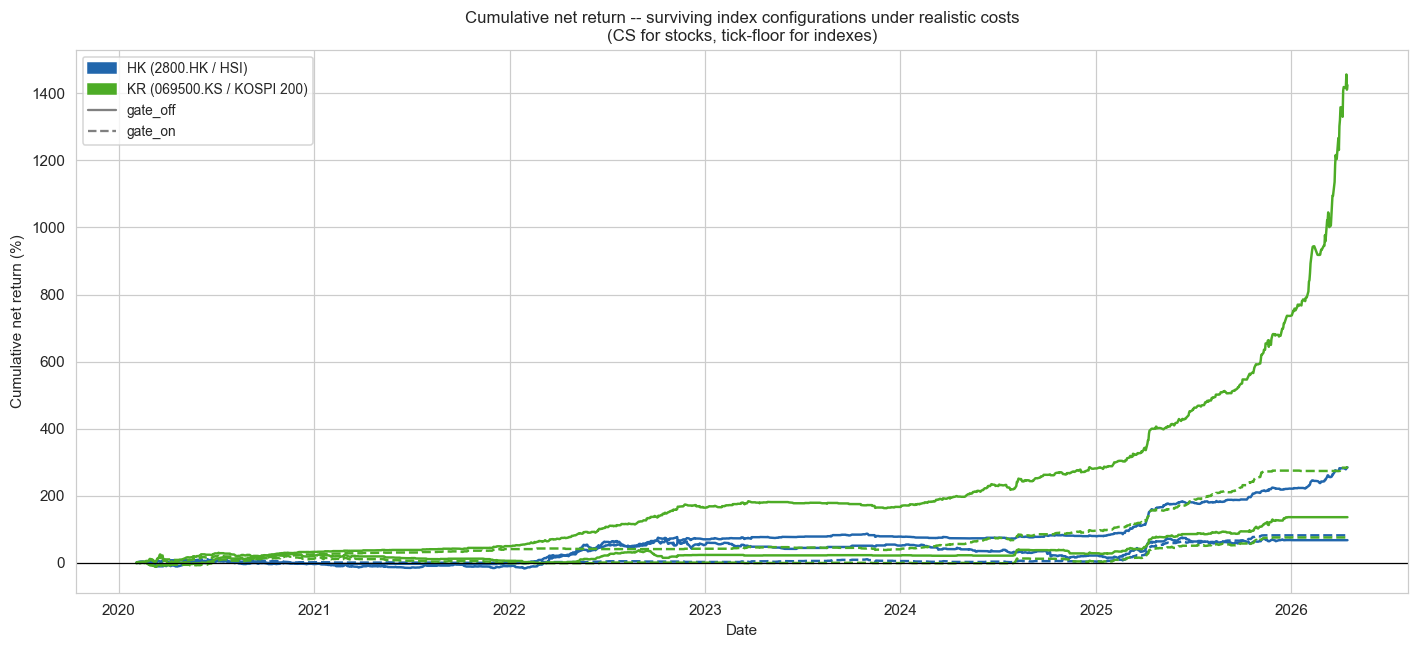

In [5]:
survivor_files = [
    ('index_hk', 'gap',  'gate_off', 'backtest_lgbm_index_hk_gap_index_threshold_gate_off_cs.csv'),
    ('index_hk', 'gap',  'gate_on',  'backtest_lgbm_index_hk_gap_index_threshold_gate_on_cs.csv'),
    ('index_hk', 'cc',   'gate_off', 'backtest_lgbm_index_hk_cc_index_threshold_gate_off_cs.csv'),
    ('index_kr', 'gap',  'gate_off', 'backtest_lgbm_index_kr_gap_index_threshold_gate_off_cs.csv'),
    ('index_kr', 'gap',  'gate_on',  'backtest_lgbm_index_kr_gap_index_threshold_gate_on_cs.csv'),
    ('index_kr', 'cc',   'gate_off', 'backtest_lgbm_index_kr_cc_index_threshold_gate_off_cs.csv'),
    ('index_kr', 'cc',   'gate_on',  'backtest_lgbm_index_kr_cc_index_threshold_gate_on_cs.csv'),
]

hk_color = '#2166ac'
kr_color = '#4dac26'

fig, ax = plt.subplots(figsize=(13, 6))

for mkt, tgt, gate, fname in survivor_files:
    df = pd.read_csv(OUT / fname, parse_dates=['date'])
    cum_net = (1 + df['net_return']).cumprod() - 1
    color = hk_color if 'hk' in mkt else kr_color
    ls = '-' if 'off' in gate else '--'
    label = f'LGBM / {mkt} / {tgt} / {gate}'
    ax.plot(df['date'], cum_net * 100, color=color, ls=ls, lw=1.6, label=label)

ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative net return (%)')
ax.set_title(
    'Cumulative net return -- surviving index configurations under realistic costs\n'
    '(CS for stocks, tick-floor for indexes)',
    fontsize=11
)

hk_patch = mpatches.Patch(color=hk_color, label='HK (2800.HK / HSI)')
kr_patch = mpatches.Patch(color=kr_color, label='KR (069500.KS / KOSPI 200)')
off_line = plt.Line2D([0], [0], color='grey', lw=1.5, ls='-',  label='gate_off')
on_line  = plt.Line2D([0], [0], color='grey', lw=1.5, ls='--', label='gate_on')
ax.legend(handles=[hk_patch, kr_patch, off_line, on_line], fontsize=9, loc='upper left')

fig.tight_layout()
plt.show()

**Key observations.**

- **KR gap configurations dominate** -- the two `index_kr gap` lines (solid and dashed green) show the steepest compounding over the full sample, consistent with headline net Sharpe of 3.64 (gate_off) and 2.60 (gate_on).
- **Gate-off > gate-on** -- for both HK and KR, gate_off (solid) consistently outperforms gate_on (dashed), confirming Pass 2 diagnostics: the BTC/S&P regime gate filters out winning days.
- **2023 KR attenuation** -- the KR lines show a visible flattening or mild drawdown around 2023, corresponding to documented KOSPI gap IC attenuation (mean IC 0.001, only 5 of 12 folds positive) before recovering in 2024-2026.
- **HK cc gate-off** is the weakest survivor, with a flat-to-modest return trajectory and the lowest net Sharpe (0.55) of the seven configurations.

## Section 7 -- control_kr Coverage Before / After Stage P2-18

Before Stage P2-18, the `control_kr` universe (38 tickers) had no daily OHLCV from pykrx. Every `control_kr` backtest row fell back to the fixed 10 bps/side (20 bps round-trip) assumption used in Pass 2. Stage P2-18 pulled 67,603 rows of daily OHLCV via pykrx, fully closing the coverage gap.

| Metric | Before P2-18 | After P2-18 |
|---|---|---|
| control_kr tickers covered by CS | 0 / 38 | 38 / 38 |
| Data rows pulled | 0 | 67,603 |
| Fallback cost assumption | 20 bps r/t (fixed) | CS per-ticker per-day |
| Median CS spread (round-trip) | n/a | ~80.5 bps |
| Previously marginal positive configs | 3 | 0 (all flipped negative) |

The real CS spread for `control_kr` tickers (~80 bps round-trip) is approximately 4x the Pass 2 fixed assumption (20 bps round-trip), explaining the large downward shift.

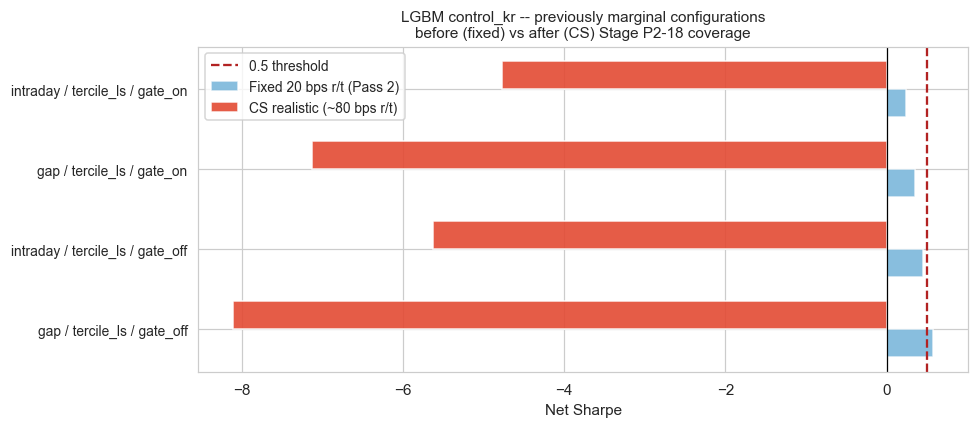

In [6]:
ckr = comp[comp['universe'] == 'control_kr'].copy()
ckr_pos = ckr[ckr['net_sharpe_fixed'] > 0].copy()
ckr_pos['label'] = ckr_pos.apply(
    lambda r: f"{r['target']} / {r['strategy']} / {r['gate']}", axis=1)
ckr_pos = ckr_pos.sort_values('net_sharpe_fixed', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(ckr_pos))
bh = 0.35
ax.barh(y - bh/2, ckr_pos['net_sharpe_fixed'], bh,
        label='Fixed 20 bps r/t (Pass 2)', color='#6baed6', alpha=0.8)
ax.barh(y + bh/2, ckr_pos['net_sharpe_cs'],    bh,
        label='CS realistic (~80 bps r/t)', color='#e34a33', alpha=0.9)
ax.axvline(0.5, color='firebrick', lw=1.5, ls='--', label='0.5 threshold')
ax.axvline(0.0, color='k', lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(ckr_pos['label'], fontsize=9)
ax.set_xlabel('Net Sharpe')
ax.set_title(
    'LGBM control_kr -- previously marginal configurations\n'
    'before (fixed) vs after (CS) Stage P2-18 coverage',
    fontsize=10)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The three configurations that looked marginally positive under the fixed 20 bps assumption all collapse to net Sharpe of -5 to -8 under real CS spreads. This is not noise: it is a systematic 4x underestimate of `control_kr` execution costs in the Pass 2 baseline. Stage P2-18 closes this coverage gap permanently -- all four stock universes (main_hk, main_kr, control_hk, control_kr) now have full empirical CS coverage.

## Section 8 -- Conclusion

**Headline.** Under realistic costs -- Corwin-Schultz empirical spreads for stock universes and exchange-tick-floor spreads for index ETFs -- **7 LightGBM index configurations clear the 0.5 net-Sharpe threshold**. All stock universes are net-negative across all 84 stock configurations.

**Deployable form.** Dual-market index-futures (HSI + KOSPI 200) on gap and cc targets, LightGBM, gate-off as default. Secondary configurations (cc gate-on for KR, gap gate-on for both markets) provide diversification at lower per-line Sharpe.

**What changed from Pass 2.** One of the eight Pass 2 fixed-spread winners (index_hk cc gate-on) is a false positive -- it does not survive tick-floor costs. Three previously marginal control_kr configurations are confirmed negative once real CS costs are applied. Five configurations that appeared negative under the earlier CS-noise-floor proxy figures are restored as survivors once the tick-floor methodology is applied to the ETF instruments.

**Open items.**
- A direct 2800.HK and 069500.KS intraday-tick pull (Bloomberg/TAQ-equivalent) would convert the tick-floor bounds into measured point estimates. The tick-floor numbers are conservative and exchange-cited, but a measured estimate is cleaner for live deployment.
- The 2023 KR attenuation is a single occurrence in the sample. Decay vs transient regime cannot be discriminated without a longer out-of-sample period.
- A 30-day live paper trade on HSI and KOSPI-200 futures with executed-spread tracking is the appropriate next operational step and the cheapest way to confirm that realized net Sharpe tracks the tick-floor projection.